<a href="https://colab.research.google.com/github/Antx0x/PMP-2026/blob/main/Lab02/Tema1_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tema 1 - laborator 2
Simularea variabilelor aleatoare

# **Ex. 1**.

Scrieţi un program în Python care să preia ca input un fişier .csv cu o listă oarecare şi să aibă ca output un număr
predeterminat de elemente din acea listă, fără repetiţie. Aplicaţi pe lista studenţilor din grupa dumneavoastră care nu
au prezentat încă o temă.

Notă: Pentru generarea unui eşantion aleator se poate apela funcţia sample din modulul random sau funcţia ran-
dom.choice cu argumentul replace=False din librăria Numpy.



In [1]:
%%writefile studenti.csv
Andrei Popescu
Maria Ionescu
Alexandru Stan
Elena Dumitrescu
Cristian Matei
Ioana Radu
Stefan Munteanu

Writing studenti.csv


In [2]:
import csv
import numpy as np

nume_fisier = "studenti.csv"
numar_extrageri = 3
lista_studenti = []

with open(nume_fisier, mode="r", encoding="utf-8") as fisier:
    cititor = csv.reader(fisier)
    for rand in cititor:
        if len(rand) > 0:
            lista_studenti.append(rand[0])

# Extragerea fara repetitie folosind NumPy (replace=False)
studenti_alesi = np.random.choice(lista_studenti, size=numar_extrageri, replace=False)

print("Studentii extrasi (cu NumPy) sunt:")
for student in studenti_alesi:
    print("- " + student)

Studenții extrași (cu NumPy) sunt:
- Alexandru Stan
- Maria Ionescu
- Cristian Matei


# **Ex. 2.**

 Doi prieteni joacă următorul joc, după următoarele reguli:
Pasul 1. Primul jucător aruncă cu o monedă.
● Dacă pică stemă, cel de-al doilea trebuie să arunce cu zarul şi să-i dea primului o sumă egală z − 3 $, unde z
este rezultatul aruncării cu zarul (a da o sumă negativă este echivalent cu a lua opusul acelei sume). Jocul
se încheie aici.
● Dacă pică ban, atunci primul jucător trebuie să-i dea celui de-al doilea 0.5 $.
Pasul n. În caz că jocul nu s-a încheiat, se reia pasul 1.
Astfel, jocul se opreşte la pasul corespunzător obţinerii stemei de către primul jucător.


**a)** Ce fel de distribuţie urmează N, numărul de paşi ai jocului?



Distribuția geometrică modelează exact numărul de încercări independente (aruncări cu moneda) necesare până la apariția primului succes (apariția stemei, care oprește jocul).Probabilitatea ca jocul să dureze exact $n$ pași înseamnă să pică „ban” de $n-1$ ori și „stemă” la aruncarea cu numărul $n$:$$P(N = n) = (1 - p)^{n-1} \cdot p, \quad \text{pentru } n \in \{1, 2, 3, \dots\}$$Formula sumei totale $S$: Dacă jocul se termină la pasul $N$, înseamnă că în primii $N-1$ pași a picat „ban” (deci primul jucător a dat câte $0.5\$$ la fiecare pas, ceea ce din perspectiva sumei primite de la al doilea jucător înseamnă $-0.5\$$ pe pas), iar la pasul $N$ a picat „stemă” și a primit $z - 3\$$. Astfel:$$S = (z - 3) - 0.5 \cdot (N - 1)$$

**b)** Simulaţi în Python un astfel de joc. Variabilele care ne interesează sunt N şi suma totală S pe care cel de-al
doilea jucător trebuie să i-o dea primului.

In [3]:
import random

def simuleaza_un_joc(probabilitate_stema=0.5):
    N = 0       # Numarul de pasi ai jocului
    S = 0.0     # Suma totala pe care al doilea jucator i-o da primului

    while True:
        N = N + 1  # Trecem la un nou pas (o noua aruncare de moneda)

        # Generam un numar intre 0 si 1. Daca e mai mic decat probabilitatea stemei,
        # consideram ca a picat STEMA. Altfel, a picat BAN.
        aruncare_moneda = random.random()

        if aruncare_moneda < probabilitate_stema:
            # A picat STEMA -> Al doilea jucator arunca zarul (valori de la 1 la 6)
            z = random.randint(1, 6)
            S = S + (z - 3)
            break  # Jocul se incheie aici, iesim din bucla while
        else:
            # A picat BAN -> Primul jucator ii da celui de-al doilea 0.5 $
            # (deci suma primita de primul jucator scade cu 0.5 $)
            S = S - 0.5

    return N, S

# Rulam un singur joc cu o moneda corecta (p = 0.5)
pasi, suma = simuleaza_un_joc(0.5)

print(f"Jocul s-a incheiat dupa N = {pasi} pasi.")
print(f"Suma totala S (primita de primul jucator) este: {suma} $")

Jocul s-a incheiat dupa N = 1 pasi.
Suma totala S (primita de primul jucator) este: 2.0 $


**c)** Prin simularea unui număr mare de astfel de jocuri, determinaţi cu aproximaţie media lui S şi reprezentaţi grafic
(printr-o histogramă) distribuţia acesteia.

Media aproximata a sumei S (pentru p = 0.5) este: -0.0024 $


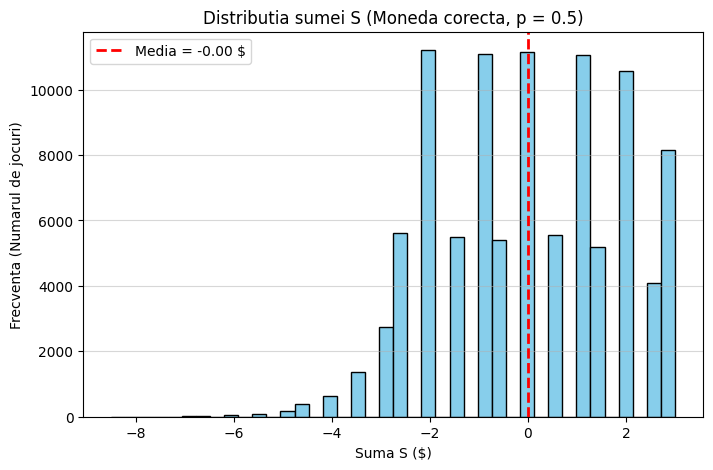

In [4]:
import matplotlib.pyplot as plt

numar_simulari = 100000  # Simulam 100.000 de jocuri
lista_S = []             # Aici salvam suma S din fiecare joc

for i in range(numar_simulari):
    N, S = simuleaza_un_joc(0.5)
    lista_S.append(S)

# Calculam media sumei S
media_S = sum(lista_S) / numar_simulari
print(f"Media aproximata a sumei S (pentru p = 0.5) este: {media_S:.4f} $")

# Reprezentarea grafica (Histograma)
plt.figure(figsize=(8, 5))
plt.hist(lista_S, bins=40, color='skyblue', edgecolor='black')
plt.axvline(media_S, color='red', linestyle='dashed', linewidth=2, label=f'Media = {media_S:.2f} $')

plt.title("Distributia sumei S (Moneda corecta, p = 0.5)")
plt.xlabel("Suma S ($)")
plt.ylabel("Frecventa (Numarul de jocuri)")
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

**d)** Ce se întâmplă dacă moneda este măsluită? Încercaţi să refaceţi pct. c) cu o probabilitate de apariţie a stemei
p = 0.3, respectiv p = 0.7.

Media aproximata a sumei S pentru p = 0.3 este: -0.6621 $
Media aproximata a sumei S pentru p = 0.7 este: 0.2827 $


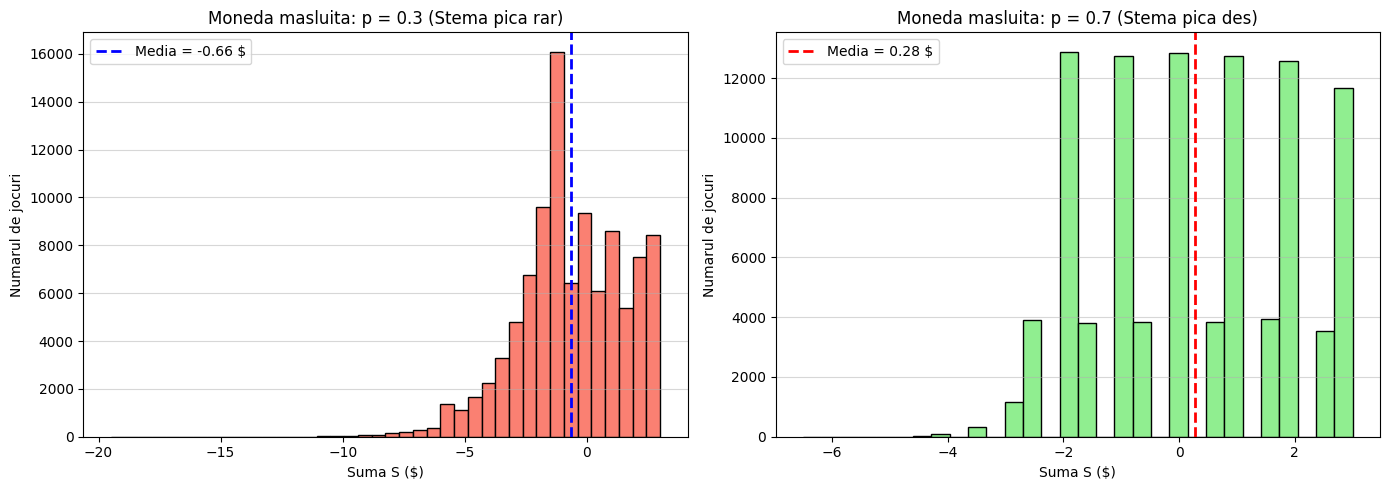

In [5]:
numar_simulari = 100000

# Simulare pentru p = 0.3
lista_S_03 = []
for i in range(numar_simulari):
    N, S = simuleaza_un_joc(0.3)
    lista_S_03.append(S)

media_S_03 = sum(lista_S_03) / numar_simulari
print(f"Media aproximata a sumei S pentru p = 0.3 este: {media_S_03:.4f} $")

# Simulare pentru p = 0.7
lista_S_07 = []
for i in range(numar_simulari):
    N, S = simuleaza_un_joc(0.7)
    lista_S_07.append(S)

media_S_07 = sum(lista_S_07) / numar_simulari
print(f"Media aproximata a sumei S pentru p = 0.7 este: {media_S_07:.4f} $")

plt.figure(figsize=(14, 5))

# Graficul din stanga (p = 0.3)
plt.subplot(1, 2, 1)
plt.hist(lista_S_03, bins=40, color='salmon', edgecolor='black')
plt.axvline(media_S_03, color='blue', linestyle='dashed', linewidth=2, label=f'Media = {media_S_03:.2f} $')
plt.title("Moneda masluita: p = 0.3 (Stema pica rar)")
plt.xlabel("Suma S ($)")
plt.ylabel("Numarul de jocuri")
plt.legend()
plt.grid(axis='y', alpha=0.5)

# Graficul din dreapta (p = 0.7)
plt.subplot(1, 2, 2)
plt.hist(lista_S_07, bins=30, color='lightgreen', edgecolor='black')
plt.axvline(media_S_07, color='red', linestyle='dashed', linewidth=2, label=f'Media = {media_S_07:.2f} $')
plt.title("Moneda masluita: p = 0.7 (Stema pica des)")
plt.xlabel("Suma S ($)")
plt.ylabel("Numarul de jocuri")
plt.legend()
plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

# Ex. 3.
Într-o frizerie, trei frizeri îşi tund clienţii cu următoarele viteze medii: primul cu 3 clienţi pe oră, al doilea cu 6 pe
oră iar al treilea cu 4 pe oră. Astfel, timpul de servire al unui client este modelat de distribuţii exponenţiale cu parametrii
λ1 = 3 h−1
, λ2 = 6 h−1
, respectiv λ3 = 4 h−1

, iar probabilităţile de preluare a unui client de către un anumit frizer sunt

3/13, 6/13, respectiv 4/13 (de ce?). Fie X timpul de servire pentru un client.
Generaţi 10000 de valori pentru X, şi în felul acesta estimaţi media şi deviaţia standard a lui X. Realizaţi un grafic
aproximativ al densităţii distribuţiei lui X.
Notă: Distribuţia Exp(λ) se poate apela prin random.exponential(scale=1/λ) în Numpy, sau cu stats.expon(scale=1/λ)
în Scipy. Având în vedere că X are o distribuţie continuă, densitatea aproximativă acesteia se poate vizualiza folosind
funcţia plot_kde din librăria Arviz.

In [6]:
!pip install arviz

Media estimata a timpului de servire X: 0.2313 ore (aprox. 13.9 minute)
Deviatia standard estimata a lui X: 0.2513 ore


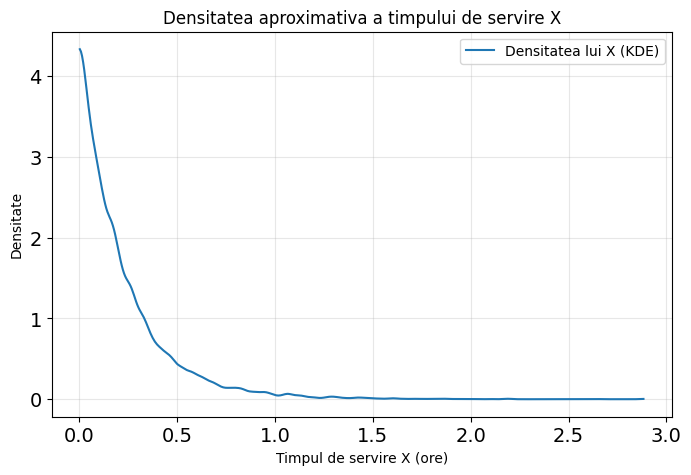

In [7]:
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

# 1. Definim datele problemei
numar_simulari = 10000

# Vitezele frizerilor (parametrii lambda)
lambda1 = 3
lambda2 = 6
lambda3 = 4

# Probabilitatile de preluare a unui client
p1 = 3 / 13
p2 = 6 / 13
p3 = 4 / 13

# 2. Generam cele 10000 de valori pentru timpul de servire X
lista_X = []

for i in range(numar_simulari):
    # Alegem mai intai la ce frizer merge clientul (1, 2 sau 3)
    # tinand cont de probabilitatile p1, p2, p3
    frizer_ales = np.random.choice([1, 2, 3], p=[p1, p2, p3])

    # In functie de frizerul ales, generam timpul de tuns (in ore)
    # folosind distributia exponentiala cu scale = 1 / lambda
    if frizer_ales == 1:
        timp = np.random.exponential(scale=1/lambda1)
    elif frizer_ales == 2:
        timp = np.random.exponential(scale=1/lambda2)
    else:
        timp = np.random.exponential(scale=1/lambda3)

    lista_X.append(timp)

# Transformam lista intr-un array NumPy pentru a calcula usor media si deviatia
X = np.array(lista_X)

# 3. Estimam media si deviatia standard a lui X
media_X = np.mean(X)
deviatia_std_X = np.std(X)

print(f"Media estimata a timpului de servire X: {media_X:.4f} ore (aprox. {media_X * 60:.1f} minute)")
print(f"Deviatia standard estimata a lui X: {deviatia_std_X:.4f} ore")

# 4. Graficul aproximat al densitatii folosind functia plot_kde din Arviz
plt.figure(figsize=(8, 5))
az.plot_kde(X, label="Densitatea lui X (KDE)")

plt.title("Densitatea aproximativa a timpului de servire X")
plt.xlabel("Timpul de servire X (ore)")
plt.ylabel("Densitate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()